# 🧠 Visualizando Mi Primera Neurona

Este notebook incluye gráficos para entender cómo la red "ve" la imagen y cómo los pesos filtran la información. La secuencia es: **entrada** → **pesos** → **estructura** → **ReLU** → **cálculo con nuestra imagen** → **caso negativo** (imagen gris).

En la vida real, las imágenes no son solo blanco (1) o negro (0), sino que tienen matices. Además, las redes neuronales prefieren trabajar con números pequeños, así que lo primero que hacemos es **normalizar los datos** (dividir el valor 0–255 entre 255 para que quede entre 0 y 1).

Imagina que queremos detectar un **borde vertical fuerte** (luz a la izquierda, sombra a la derecha) en una cuadrícula de $2 \times 2$. En los siguientes apartados verás cada paso con su explicación y su gráfico correspondiente.

### Arquitectura de esta red

En este ejemplo la red es un **perceptrón** (red de una sola capa):

| Capa | Qué es | En nuestro caso |
|------|--------|------------------|
| **Capa de entrada** | Son las *entradas* que recibe la red (no son neuronas que calculen). | **4 entradas**: los 4 píxeles de la imagen $2\\times 2$, normalizados (un valor por píxel). |
| **Capa(s) oculta(s)** | Neuronas intermedias entre entrada y salida; permiten aprender patrones complejos. | **Ninguna**: este perceptrón no tiene capa oculta. |
| **Capa de salida** | Neuronas que producen el resultado final. | **1 neurona**: recibe las 4 entradas, tiene 4 pesos (uno por entrada), un sesgo y una función de activación (ReLU). Su salida es un único número. |

**Resumen:** $4 \\text{ entradas} \\rightarrow 1 \\text{ neurona de salida}$ (4 pesos + sesgo + ReLU). Es la arquitectura más simple posible; en redes más grandes habría varias neuronas en capas ocultas y/o varias salidas.

## 1. La Entrada: Imagen en Escala de Grises y Visualización

Aquí tienes los valores de los píxeles (0 = Negro absoluto, 255 = Blanco puro):

| Píxel       | Valor (0-255) | Normalizado (0 a 1) | Estado Visual   |
|-------------|---------------|---------------------|-----------------|
| Arriba-Izq  | 250           | 0.98                | Casi blanco     |
| Arriba-Der  | 20            | 0.08                | Casi negro      |
| Abajo-Izq   | 240           | 0.94                | Gris muy claro  |
| Abajo-Der   | 10            | 0.04                | Casi negro      |

A continuación definimos y visualizamos la imagen de entrada.

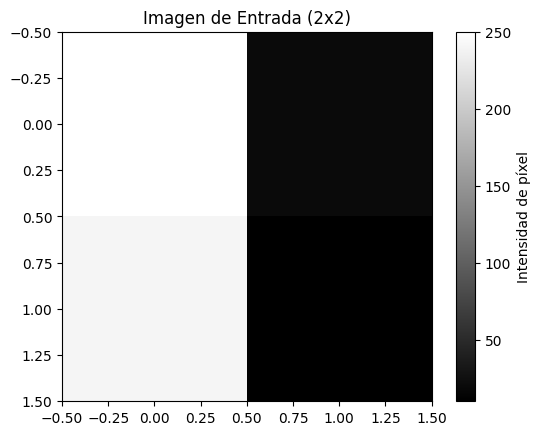

In [15]:
# Librerías estándar para cálculo numérico y visualización
import numpy as np
import matplotlib.pyplot as plt

# --- Imagen de entrada (2x2 píxeles) ---
# Simulamos una imagen pequeña: valores altos (250, 240) = zona clara,
# valores bajos (20, 10) = zona oscura. La neurona aprenderá a detectar patrones.
imagen_original = np.array([[250, 20], 
                            [240, 10]])

# Mostramos la imagen en escala de grises para ver qué "ve" la red como entrada
plt.imshow(imagen_original, cmap='gray')
plt.title("Imagen de Entrada (2x2)")
plt.colorbar(label="Intensidad de píxel")
plt.show()

# Normalización: llevamos los píxeles al rango [0, 1] dividiendo por 255.
# Esto evita que valores muy grandes dominen el cálculo y estabiliza el entrenamiento.
# flatten() convierte la matriz 2x2 en un vector de 4 valores para la neurona.
activaciones_entrada = imagen_original.flatten() / 255.0

## 2. Pesos: La Neurona "Detector de Bordes" y su Visualización

Nuestra neurona tiene unos pesos entrenados para ignorar el ruido y enfocarse solo en la **diferencia de luz entre la izquierda y la derecha**. Los pesos actúan como una "máscara"; a continuación los graficamos para ver qué patrón está buscando la neurona.

| Peso (w)     | Col. Izquierda | Col. Derecha | Explicación                              |
|--------------|----------------|--------------|------------------------------------------|
| Fila Arriba  | $+0.8$         | $-0.8$       | Premia luz a la izq, castiga luz a la der |
| Fila Abajo   | $+0.8$         | $-0.8$       | Refuerza el patrón vertical              |

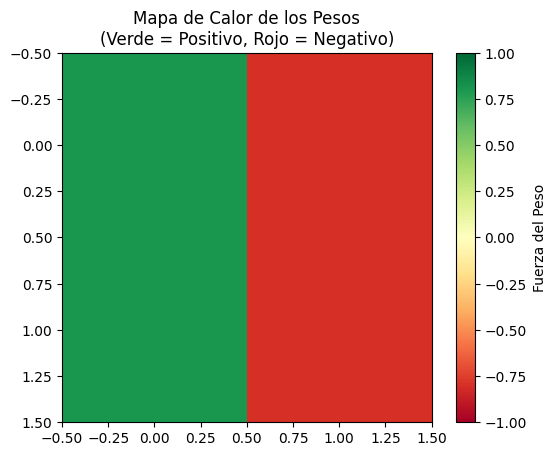

In [16]:
# Pesos de la neurona: definen qué patrón busca (como un "filtro" o "máscara").
# Valores positivos (0.8) refuerzan esa zona; negativos (-0.8) la restan.
# Esta configuración busca "zona clara arriba-izquierda, zona oscura abajo-derecha".
pesos = np.array([[0.8, -0.8], 
                  [0.8, -0.8]])

# Mapa de calor: verde = peso positivo, rojo = peso negativo.
# vmin/vmax fijan la escala para que la interpretación sea clara.
plt.imshow(pesos, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title("Mapa de Calor de los Pesos\n(Verde = Positivo, Rojo = Negativo)")
plt.colorbar(label="Fuerza del Peso")
plt.show()

# Aplanamos los pesos para poder hacer el producto escalar con las activaciones de entrada
pesos_flat = pesos.flatten()

## 3. La Estructura de la Red

Tenemos **4 entradas** (los 4 píxeles normalizados) que se conectan a **una sola neurona** con 4 pesos y un sesgo. Antes de ver el resultado numérico, necesitamos la función de activación que aplicaremos a la salida: **ReLU**.

## 4. La Función de Activación ReLU

ReLU convierte cualquier valor negativo en 0 y deja los positivos igual. Así, si la suma ponderada es negativa, la neurona "se apaga". En el siguiente código definimos ReLU y la graficamos.

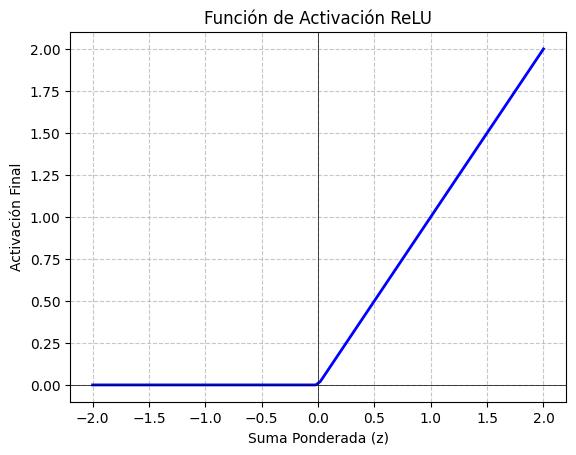

In [17]:
# ReLU (Rectified Linear Unit): max(0, x). Si la suma ponderada es negativa, la salida es 0;
# si es positiva, la salida es el mismo valor. Introduce no linealidad y "apaga" neuronas.
def relu(x):
    return np.maximum(0, x)

# Generamos 100 puntos entre -2 y 2 para dibujar la curva de ReLU
x_range = np.linspace(-2, 2, 100)
y_range = relu(x_range)

# Graficamos: a la izquierda de 0 la función vale 0; a la derecha, crece en línea recta
plt.plot(x_range, y_range, label='ReLU', color='blue', linewidth=2)
plt.axhline(0, color='black', linewidth=0.5)  # Eje horizontal
plt.axvline(0, color='black', linewidth=0.5)  # Eje vertical
plt.title("Función de Activación ReLU")
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlabel("Suma Ponderada (z)")
plt.ylabel("Activación Final")
plt.show()

## 5. Cálculo Final: Suma Ponderada, Sesgo y ReLU (con Verificación Visual)

Multiplicamos cada píxel normalizado por su peso. Esto es lo que la red "piensa":

| Ubicación   | Activación (a) | × | Peso (w) | Resultado parcial |
|-------------|----------------|---|----------|-------------------|
| Arriba-Izq  | $0.98$         | × | $0.8$    | $+0.784$          |
| Arriba-Der  | $0.08$         | × | $-0.8$   | $-0.064$          |
| Abajo-Izq   | $0.94$         | × | $0.8$    | $+0.752$          |
| Abajo-Der   | $0.04$         | × | $-0.8$   | $-0.032$          |
| **Suma (a·w)**  |            |   |          | **$1.44$**        |

Aquí entra el **Sesgo** ($b = -0.5$). Con un poco de "ruido" en la cámara, no queremos que la neurona se active por cualquier sombrita.

- **Suma ponderada:** $z = 1.44 + (-0.5) = \mathbf{0.94}$
- **Activación final (ReLU):** Como $0.94 > 0$, la neurona se dispara con salida $0.94$. El gráfico siguiente muestra ese punto sobre la curva ReLU.

**¿Qué pasaría si la imagen fuera gris plano** (ej. todos los píxeles en 128)?  
La suma de los pesos positivos y los negativos daría 0. Al sumarle el sesgo de $-0.5$, el resultado sería $-0.5$. La función ReLU lo convertiría en 0. **¡La neurona se queda dormida porque no hay un borde!**

**Resumen:** $\text{Activación} = \text{ReLU}\left( \sum (a_i \cdot w_i) + b \right)$

A continuación ejecutamos el cálculo y vemos dónde cae nuestra neurona en la curva ReLU.

Suma ponderada (z): 0.94
Activación final: 0.94


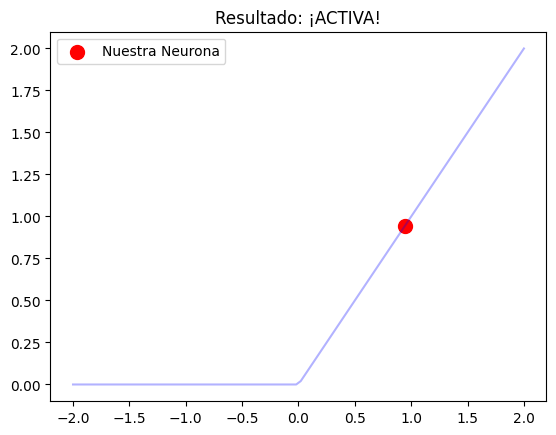

In [18]:
# Sesgo (bias): desplaza la decisión; un valor negativo exige más "evidencia" para activar
sesgo = -0.5

# z = w1*x1 + w2*x2 + w3*x3 + w4*x4 + b (producto escalar entrada·pesos + sesgo)
suma_ponderada = np.dot(activaciones_entrada, pesos_flat) + sesgo

# Aplicamos ReLU: si z <= 0 la neurona queda "apagada" (salida 0)
activacion_final = relu(suma_ponderada)

print(f"Suma ponderada (z): {suma_ponderada:.2f}")
print(f"Activación final: {activacion_final:.2f}")

# Ubicamos nuestro resultado sobre la curva ReLU para ver si la neurona se activa o no
plt.plot(x_range, y_range, color='blue', alpha=0.3)
plt.scatter([suma_ponderada], [activacion_final], color='red', s=100, label='Nuestra Neurona')
plt.title(f"Resultado: {'¡ACTIVA!' if activacion_final > 0 else 'APAGADA'}")
plt.legend()
plt.show()

## 6. Caso negativo: imagen gris (sin borde)

Si la imagen es **gris uniforme** (todos los píxeles iguales), no hay diferencia entre izquierda y derecha: la suma de (a·w) se anula y, con el sesgo negativo, la neurona **no se activa**. Primero mostramos la imagen; luego calculamos la salida y la ubicamos en la curva ReLU.

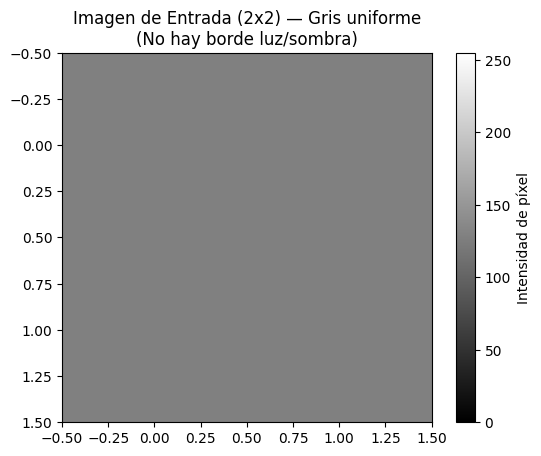

In [19]:
# Imagen gris uniforme: todos los píxeles en 128 (gris medio)
imagen_gris = np.array([[128, 128],
                        [128, 128]])

# Visualización: se ve como un cuadrado gris homogéneo (sin borde)
plt.imshow(imagen_gris, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen de Entrada (2x2) — Gris uniforme\n(No hay borde luz/sombra)")
plt.colorbar(label="Intensidad de píxel")
plt.show()

# Misma normalización que antes
activaciones_gris = imagen_gris.flatten() / 255.0

Con la **misma neurona** (mismos pesos y sesgo) calculamos la salida. La suma ponderada será distinta y, con el sesgo negativo, la neurona quedará apagada. El siguiente gráfico muestra el punto sobre la curva ReLU.

Suma ponderada (z) con imagen gris: -0.50
Activación final (ReLU): 0.00
Resultado: APAGADA (neurona dormida)


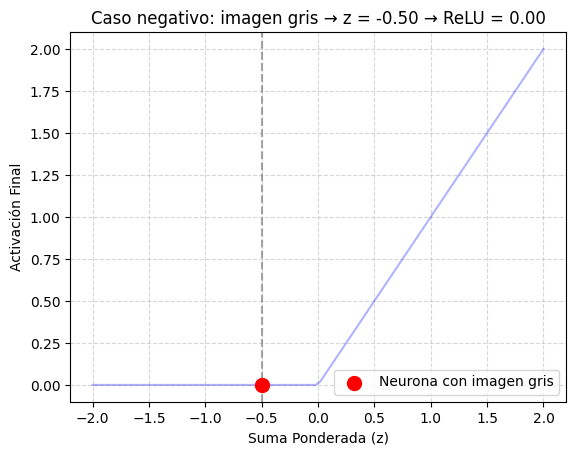

In [20]:
# Cálculo: suma ponderada + sesgo (usamos los mismos pesos y sesgo que antes)
suma_ponderada_gris = np.dot(activaciones_gris, pesos_flat) + sesgo
activacion_final_gris = relu(suma_ponderada_gris)

print(f"Suma ponderada (z) con imagen gris: {suma_ponderada_gris:.2f}")
print(f"Activación final (ReLU): {activacion_final_gris:.2f}")
print(f"Resultado: {'¡ACTIVA!' if activacion_final_gris > 0 else 'APAGADA (neurona dormida)'}")

# Ubicamos el resultado sobre la curva ReLU: cae en la zona donde ReLU = 0
plt.plot(x_range, y_range, color='blue', alpha=0.3)
plt.scatter([suma_ponderada_gris], [activacion_final_gris], color='red', s=100, 
            label='Neurona con imagen gris', zorder=5)
plt.axvline(suma_ponderada_gris, color='gray', linestyle='--', alpha=0.7)
plt.title(f"Caso negativo: imagen gris → z = {suma_ponderada_gris:.2f} → ReLU = {activacion_final_gris:.2f}")
plt.xlabel("Suma Ponderada (z)")
plt.ylabel("Activación Final")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

---

## ¿Qué acabas de construir?

Acabas de crear un **Perceptrón funcional** con visualización de datos. Este es el átomo básico de todo lo que hace Google, OpenAI o Tesla.